# Konwolucyjne Sieci Neuronowe (CNN) i przetwarzanie obrazów

Konwolucyjne sieci neuronowe (ang. *Convolutional Neural Networks*, CNN) to głębokie sieci neuronowe szczególnie skuteczne w analizie obrazów. Wykorzystują operację konwolucji, która pozwala na automatyczną ekstrakcję cech z danych wejściowych.

W miarę przechodzenia przez kolejne warstwy sieci:

- dane wejściowe są przekształcane w coraz bardziej abstrakcyjne reprezentacje,
- model wykrywa coraz bardziej złożone wzorce,
- stopniowo zmniejsza się rozmiar przestrzenny reprezentacji danych.

---

# Architektura CNN

Sieci CNN budowane są z powtarzających się bloków warstw, które przetwarzają obraz krok po kroku.

Typowy przepływ danych wygląda następująco:

$$
\text{Obraz wejściowy}
\rightarrow
\text{Warstwa konwolucyjna}
\rightarrow
\text{Funkcja aktywacji}
\rightarrow
\text{Pooling}
\rightarrow
\text{(kolejne bloki konwolucyjne)}
\rightarrow
\text{Flatten}
\rightarrow
\text{Warstwy w pełni połączone}
\rightarrow
\text{Softmax}
\rightarrow
\text{Predykcja klasy}
$$

---

## Interpretacja przepływu danych

1. **Obraz wejściowy**

   Do sieci trafia obraz, np. w postaci tensora:

   $$
   H \times W \times C
   $$

   gdzie:

   - $H$ – wysokość obrazu  
   - $W$ – szerokość obrazu  
   - $C$ – liczba kanałów (np. 1 dla obrazów grayscale lub 3 dla RGB)

---

2. **Warstwy konwolucyjne (splotowe)**

   Pierwsze warstwy uczą się wykrywać **proste wzorce**, takie jak krawędzie i tekstury.

   W głębszych warstwach powstają **bardziej złożone reprezentacje**, np.:

   - fragmenty obiektów
   - charakterystyczne struktury w obrazie

---

3. **Pooling**

   Warstwy pooling zmniejszają rozmiar map cech:

   $$
   H \times W \rightarrow \frac{H}{2} \times \frac{W}{2}
   $$

   Dzięki temu:

   - zmniejsza się liczba parametrów,
   - sieć staje się bardziej odporna na drobne przesunięcia obiektów.

---

4. **Flatten**

   Po kilku blokach konwolucyjnych mapy cech są **spłaszczane do wektora**:

   $$
   H \times W \times C \rightarrow N
   $$

   gdzie $N$ to liczba neuronów w warstwie wejściowej klasyfikatora.

---

5. **Warstwy w pełni połączone**

   Warstwy te łączą wszystkie wyekstrahowane wcześniej cechy i uczą się zależności między nimi w celu klasyfikacji obrazu.

---

6. **Warstwa wyjściowa**

Ostatnia warstwa przekształca wyjście modelu w **prawdopodobieństwa** klas przy użyciu funkcji Softmax (dla klasyfikacji wieloklasowej) lub Sigmoid (dla klasyfikacji binarnej).

---

W kolejnej części omówione zostaną szczegółowo poszczególne typy warstw stosowanych w sieciach CNN.

![CNN](https://softwebsolutions.b-cdn.net/wp-content/uploads/2023/11/Blog__CNN-vs-RNN-vs-ANN-04.webp)




<p align="center">
<b>Rysunek.</b> Architektura CNN

Źródło: https://www.softwebsolutions.com/resources/difference-between-cnn-rnn-ann/
</p>



Ciekawa prezentacja graficzna sieci jest tez widoczna tutaj: https://poloclub.github.io/cnn-explainer/

**Cel i przebieg ćwiczenia**

Celem laboratorium jest zapoznanie się z praktycznym zastosowaniem konwolucyjnych sieci neuronowych w przetwarzaniu obrazów oraz klasyfikacji danych wizualnych.

Zakres ćwiczenia obejmuje:

1. **Przetwarzanie obrazów – filtry i operacja splotu**.
   Analiza działania operacji konwolucji na przykładzie gotowego kodu w Keras, z wykorzystaniem różnych masek filtrujących.
2. **Implementacja przykładowej funkcji splotu**.
   Samodzielna implementacja operacji konwolucji w celu lepszego zrozumienia jej mechanizmu obliczeniowego.


3. **Klasyfikacja obrazów z użyciem CNN – zbiór Fashion MNIST**.
   Budowa, trenowanie oraz ewaluacja modelu konwolucyjnej sieci neuronowej dla zadania klasyfikacji obrazów odzieży. Porównanie skutecnzości sieci CNN z FNN.


4. **Budowa sieci CNN dla klasycznego zbioru klasyfikacji obrazów**.
   Zastosować architekturę CNN do klasyfikacji obrazów ze zbioru **CIFAR-10**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

## Przetwarzanie obrazów, filtry i operacja splotu.

W tej części jest gotowy do wykonania kod, który implementuje operacje splotu w keras dla różnych filtrów.

In [2]:
# Generowanie losowych danych
np.random.seed(37)
image = np.random.rand(1, 10, 10, 1)

### Interpretacja kształtu danych

Wygenerowany tensor ma kształt **(1, 10, 10, 1)**, co w konwencji `channels_last` (stosowanej domyślnie w Keras) oznacza:

* **1** – liczba próbek w batchu (*batch size*),
* **10** – wysokość obrazu (*height*),
* **10** – szerokość obrazu (*width*),
* **1** – liczba **kanałów** (*channels*), czyli obraz w skali szarości. Dla obrazów w skali RBG byłyby 3 kanały.

Z punktu widzenia warstwy `Conv2D` jest to czterowymiarowy tensor **wejściowy** reprezentujący pojedynczy obraz o rozmiarze 10×10 pikseli z jednym kanałem intensywności.


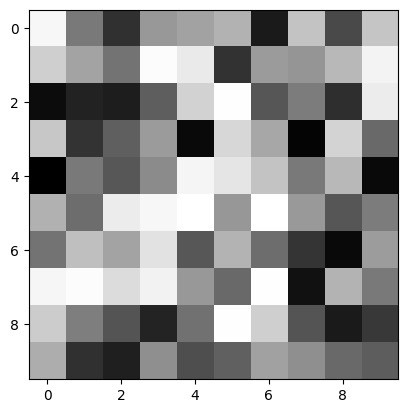

In [3]:
imgplot = plt.imshow(image[0,:,:,0], cmap='gray')
plt.show()

---

## Wyjaśnienie operacji splotu (Conv2D)

Warstwa `Conv2D` wykonuje operację **konwolucji** pomiędzy wejściowym tensorem obrazu a zestawem uczonych filtrów (jąder).

---

###  Konfiguracja warstwy

W analizowanej konfiguracji:

* **`filters = 1`**
  Model uczy się jednego filtra (maski 3×3) → na wyjściu powstaje **jedna mapa cech**.

* **`kernel_size = (3, 3)`**
  Filtr ma wymiar **3×3 piksele**.

* **`padding = 'same'`**
  Wyjście ma taki sam wymiar przestrzenny jak wejście (**10×10**) dzięki dopełnieniu zerami na brzegach.

* **`activation = None`**
  Brak funkcji aktywacji → warstwa realizuje wyłącznie **liniową operację splotu**.

* **`input_shape = (10, 10, 1)`**
  Wejście: obraz **10×10** z jednym kanałem (skala szarości).

---

## Mechanizm działania

1. Filtr 3×3 jest przesuwany po całym obrazie.
2. W każdej pozycji obliczana jest suma iloczynów elementów filtra i lokalnego fragmentu obrazu (iloczyn skalarny).
3. Wynik zapisywany jest w odpowiedniej pozycji mapy cech.

---

## Formalna definicja

Dla pojedynczego kanału operacja splotu ma postać:

$$
Y(i,j) = \sum_{m=0}^{2} \sum_{n=0}^{2} X(i+m, j+n) \cdot K(m,n)
$$

gdzie:

* ( X ) — obraz wejściowy
* ( K ) — macierz filtra (jądro)
* ( Y ) — wynikowa mapa cech
* i,j - kolejne piksele obrazu

---

## Interpretacja praktyczna

W procesie uczenia warstwa optymalizuje wartości wag filtra tak, aby wykrywać istotne lokalne wzorce, np.:

* krawędzie,
* tekstury,
* proste struktury geometryczne.

W głębszych warstwach sieci wzorce te stają się coraz bardziej abstrakcyjne.


### Budowa przykładowej operacji splotu w Keras

In [4]:
# Definicja prostego modelu ze splotem
model = Sequential([
    Conv2D(filters=1, kernel_size=(3, 3), padding='same', activation=None, input_shape=(10, 10, 1))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Uwaga! Poniższe filtry są zdefiniowane dla 'warst splotowych' **wewnątrz** sieci neuronowej, dlatego operacja `reshape` ma inny kształt niż pokazany powyżej, przykładowy obrazek wejściowy.

In [5]:
# Prosty filtr na wykrywanie krawędzi
kernel = np.array([[ -1, -1, -1],
                   [ -1,  8, -1],
                   [ -1, -1, -1]])


# Dopasowanie rozmiaru danych miedzy filtrem i splotem
# wymiary warstwy:
# (długość, szerokość, ilość kanałów wejściowych, ilość kanałów wyjściowych)
kernel = kernel.reshape((3, 3, 1, 1))

In [6]:
# Dodaj manualnie wagi konwolucji
model.layers[0].set_weights([kernel, np.array([0])])

In [7]:
# Sprawdzenie czy wagi filtra sa dobrze zapisane
model.layers[0].get_weights()

[array([[[[-1.]],
 
         [[-1.]],
 
         [[-1.]]],
 
 
        [[[-1.]],
 
         [[ 8.]],
 
         [[-1.]]],
 
 
        [[[-1.]],
 
         [[-1.]],
 
         [[-1.]]]], dtype=float32),
 array([0.], dtype=float32)]

In [8]:
# Operacja splotu
convolved_image = model.predict(image)
convolved_image = convolved_image[0, :, :, 0]  # usuwanie niepotrzebnych wymiarów

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


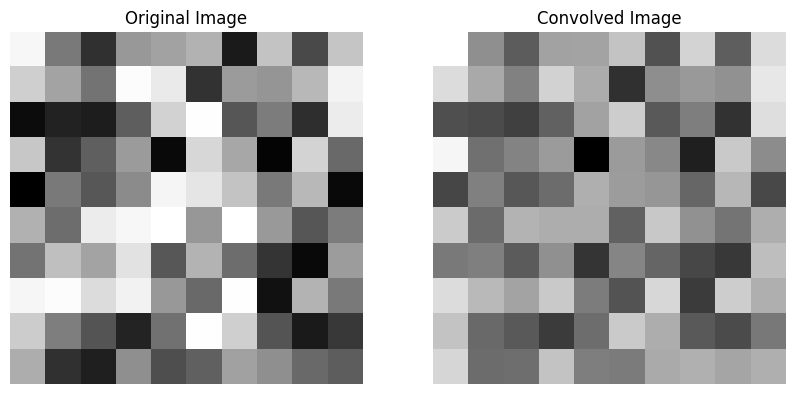

In [9]:
# Pokazanie wyników splotu
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image[0, :, :, 0], cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(convolved_image, cmap='gray')
ax[1].set_title("Convolved Image")
ax[1].axis("off")

plt.show()

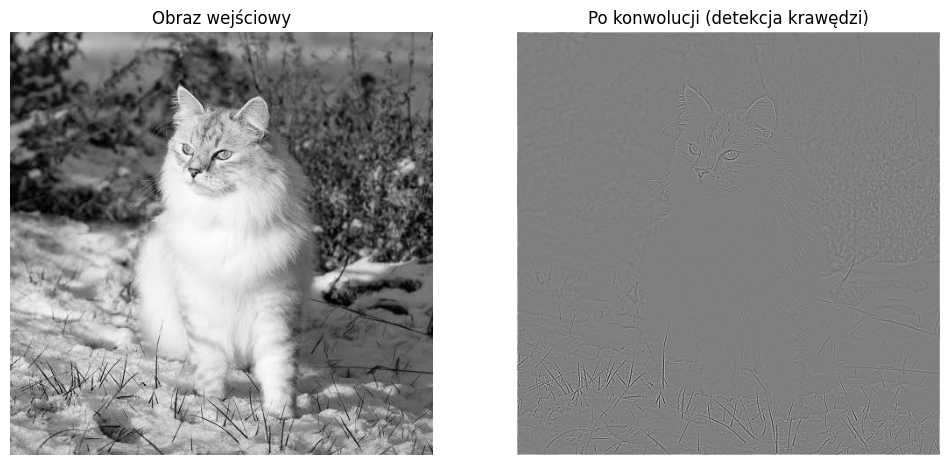

In [10]:
# Prezentacja konwolucji na elemencie animalnym (oryginalny rozmiar, kot syberyjski)

import requests
from PIL import Image
from io import BytesIO

# ---------------------------
# Pobranie obrazka kota
# ---------------------------
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRlbIjt1cZo1wLmHmUGmjo2ZGyS2HZMf2PsYDfBbrpa5tNBUSXkSKEMxMs1huQsQf-Hsv7Hy3jJ&s=10"

response = requests.get(url)
img = Image.open(BytesIO(response.content))

# konwersja do grayscale
img = img.convert("L")

# zamiana na tablicę i normalizacja
img_array = np.array(img) / 255.0

# pobranie wymiarów obrazu
H, W = img_array.shape

# dodanie wymiaru batch i kanału
input_image = img_array.reshape(1, H, W, 1)

# ---------------------------
# Definicja modelu CNN
# ---------------------------
model = Sequential([
    Conv2D(
        filters=1,
        kernel_size=(3,3),
        padding='same',
        activation=None,
        input_shape=(H, W, 1)
    )
])

# ---------------------------
# Ręczne ustawienie filtra (detekcja krawędzi)
# ---------------------------
kernel = np.array([
    [-1,-1,-1],
    [-1, 8,-1],
    [-1,-1,-1]
], dtype=np.float32)

kernel = kernel.reshape(3,3,1,1)
bias = np.zeros((1,), dtype=np.float32)

model.layers[0].set_weights([kernel, bias])

# ---------------------------
# Wykonanie konwolucji
# ---------------------------
filtered = model.predict(input_image, verbose=0)
filtered = filtered[0,:,:,0]

# normalizacja do wizualizacji
filtered = (filtered - filtered.min()) / (filtered.max() - filtered.min())

# ---------------------------
# Wizualizacja
# ---------------------------
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_array, cmap="gray")
plt.title("Obraz wejściowy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(filtered, cmap="gray")
plt.title("Po konwolucji (detekcja krawędzi)")
plt.axis("off")

plt.show()

In [11]:
# Inny rodzaj funkcji jądra - rozmycie gaussowskie
gaussian_kernel = np.array([[1, 2, 1],
                            [2, 4, 2],
                            [1, 2, 1]]) / 16
gaussian_kernel = gaussian_kernel.reshape((3, 3, 1, 1))
model.layers[0].set_weights([gaussian_kernel, np.array([0])])
blurred_image = model.predict(image)[0, :, :, 0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


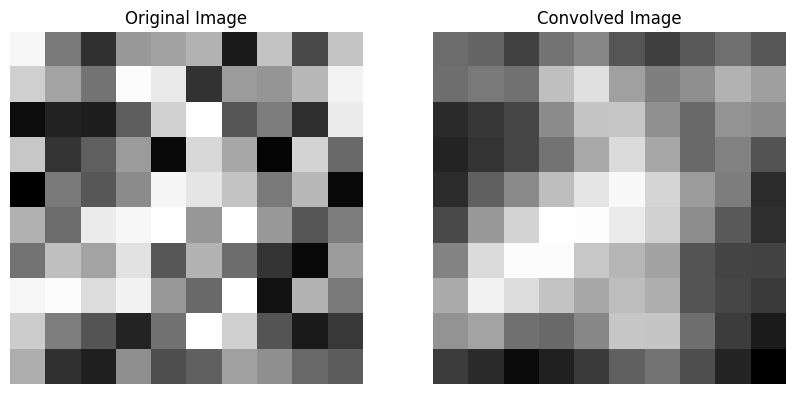

In [12]:
# Pokazanie wyników splotu
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image[0, :, :, 0], cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(blurred_image, cmap='gray')
ax[1].set_title("Convolved Image")
ax[1].axis("off")

plt.show()

## Analiza działania filtrów konwolucyjnych

---

### 1. Implementacja i porównanie filtrów w Keras

Dla wygenerowanego obrazu (`image`) należy:

* Zdefiniować odpowiednie warstwy `Conv2D` z ręcznie ustawionymi wagami (jądrami),
* Zastosować je do obrazu analogicznie jak w poprzednich przykładach,
* Porównać uzyskane wyniki.

#### Filtry do zaimplementowania:

**a) Filtr uśredniający (blur)**

```python
[[0.11111111, 0.11111111, 0.11111111],
 [0.11111111, 0.11111111, 0.11111111],
 [0.11111111, 0.11111111, 0.11111111]]
```

**b) Filtr ostrzący (sharpening)**

```python
[[ 0, -1,  0],
 [-1,  5, -1],
 [ 0, -1,  0]]
```

**c) DLA CHĘTNYCH – autorski filtr**

Zaprojektować i zdefiniować własne jądro (np. detekcja krawędzi, szkieletyzacja, filtr kierunkowy itp.).
Krótko uzasadnić jego konstrukcję.

---

### 2 Analiza filtrów na wybranym obrazie

* Wybrać dowolny obraz (np. zewnętrzny lub z `fashion-mnist`).
* Zastosować jeden powyższy filtr.
* Przedstawić:

  * obraz przed operacją,
  * obraz po operacji,
  * rozmiary tensora wejściowego i wyjściowego.

#### W opisie należy:

* Wyjaśnić wpływ filtra na strukturę obrazu,
* Odnieść uzyskane efekty do działania warstw konwolucyjnych w sieciach CNN,
* Krótko skomentować, jak ręcznie definiowane filtry mają się do filtrów uczonych w procesie treningu.

---

### Wskazówki

* Jeśli nie masz własnego obrazu, możesz użyć danych z **`fashion-mnist`** z kolejnej części notebooka.
* Dla obrazów 3-kanałowych (RGB) należy odpowiednio dopasować wymiar jądra w `Keras` (kształt `(3,3,3,1)` zamiast `(3,3,1,1)`).

---



In [ ]:
# Miejsce na kod
model = model = Sequential([
    Conv2D(
        filters=1,
        kernel_size=(3,3),
        padding='same',
        activation=None,
        input_shape=(H, W, 1)
    )
])

## 3 Implementacja operacji splotu w NumPy (bez Keras)

Zaimplementować konwolucję manualnie, wykonując poniższe kroki:

### Krok 1 — Dane wejściowe

* Wygenerować losowy obraz w skali szarości o rozmiarze **27×27** (1 kanał).

---

### Krok 2 — Definicja filtra

* Zdefiniować filtr uśredniający o wymiarze **3×3**
  (`kernel_size = 3`).

---


### Krok 3 — Padding

* Wykonać dopełnienie zerami (zero-padding),
* Szerokość paddingu:

$$
\text{padding} = \left\lfloor \frac{\text{kernel_size}}{2} \right\rfloor
$$

* Można użyć funkcji `np.pad`.


---

### Krok 4 — Implementacja splotu

1. Utworzyć macierz zer reprezentującą nowy obraz wyjściowy.
2. Dla każdego piksela:

   * wyciąć lokalne okno 3×3,
   * obliczyć sumę iloczynów z filtrem (iloczyn skalarny),
   * zapisać wynik w macierzy wyjściowej.

---

### Krok 5 — Wizualizacja wyników

* Wyświetlić:

  * obraz wejściowy,
  * obraz po konwolucji,
  * rozmiary obu macierzy.

---

### Cel ćwiczenia

* Zrozumienie matematycznej definicji konwolucji,
* Porównanie implementacji ręcznej z implementacją w `Keras`,
* Intuicyjne uchwycenie, jak działają warstwy konwolucyjne w CNN.

#### TIP

Rozmiar paddingu i jądra mogą się różnić w zależności od wielkości przetwarzanego obrazu.


In [ ]:
# Miejsce na kod

## Zadanie

### Klasyfikacja obrazów z użyciem CNN

W tym zadaniu zbudują Państwo **konwolucyjną sieć neuronową (CNN)** do klasyfikacji obrazów ze zbioru **Fashion-MNIST**.

Dataset zawiera obrazy ubrań w skali szarości o rozmiarze **28 × 28 pikseli** i jest często wykorzystywany jako przykład w zadaniach z zakresu uczenia głębokiego.

Opis zbioru danych:  
https://www.tensorflow.org/datasets/catalog/fashion_mnist?hl=pl

---

### Krok 1 — uruchomienie modelu

Poniżej znajduje się **działający przykład kodu**, który:

- wczytuje zbiór danych **Fashion-MNIST**,
- buduje **konwolucyjną sieć neuronową (CNN)**,
- trenuje model,
- ocenia jego jakość.

Państwa pierwszym zadaniem jest:

1. Uruchomić kod.
2. Sprawdzić, czy model poprawnie się trenuje.
3. Następnie przejść do kolejnego zadania.

---

### Wskazówka

Podczas początkowej pracy z modelem warto trenować sieć na **mniejszej liczbie epok**, aby:

- szybciej sprawdzić, czy model się uczy,
- skrócić czas debugowania,
- łatwiej eksperymentować z architekturą sieci.
- finalny trening na zoptymalizowanych parametrach można przyspieszyć używając GPU

Po upewnieniu się, że model działa poprawnie, można zwiększyć liczbę epok treningu.

In [ ]:
from tensorflow.keras import layers, models

In [ ]:
# Ładowanie danych fashion mnist
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

**Zadanie** Opisać dlaczego normalizacja daych jest ważna dla obrazów i CNN (wpływ na gradient różnych zakresów wartości cech)?
- ...

In [ ]:
# Normalizacja danych
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
train_images[0].shape

In [ ]:
# Pokazanie przykładowego obrazu ze zbioru danych
imgplot = plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()

In [ ]:
# Reshape danych do warstwy konwolucyjnej (batch_size, height, width, channels)
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

In [ ]:
train_images[0].shape

### NOTE

#### Dostosowanie rozmiaru danych dla sieci CNN

Dane wejściowe muszą zostać przekształcone do formatu oczekiwanego przez warstwy konwolucyjne.

Interpretacja wymiarów:

- **(28, 28)** – rozmiar obrazu (wysokość × szerokość)
- **train_images.shape[0]** – liczba próbek w zbiorze treningowym (rozmiar batcha)
- **1** – liczba kanałów obrazu (obrazy w Fashion-MNIST są w skali szarości, więc mają jeden kanał)

Ponieważ zbiór **Fashion-MNIST jest stosunkowo niewielki**, możliwe jest trenowanie modelu na całym zbiorze jednocześnie (jeden batch).

---

Dla dużych zbiorów danych trenowanie modelu na **jednym batchu** może być problematyczne.

Proszę odpowiedzieć:

**Dlaczego trenowanie sieci neuronowej na jednym bardzo dużym batchu jest niekorzystne z punktu widzenia algorytmów optymalizacyjnych?**

In [ ]:
# Prosty model CNN
model = models.Sequential([

    # Pierwsza warstwa konwolucyjna
    # Dodaje 32 filtry o rozmiarze 3x3.
    # Każdy filtr przesuwa się po obrazie i wykrywa lokalne wzorce,
    # takie jak krawędzie, tekstury lub proste kształty.
    # Funkcja aktywacji ReLU wprowadza nieliniowość i pozwala modelowi
    # uczyć się bardziej złożonych zależności.
    # Dane wejściowe mają rozmiar (28, 28, 1), czyli obraz 28x28 w skali szarości.
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),


    # Warstwa poolingowa (MaxPooling)
    # Redukuje rozmiar map cech poprzez wybieranie największej wartości
    # z każdego fragmentu 2x2 mapy cech.
    # Dzięki temu:
    # - zmniejsza się liczba parametrów w kolejnych warstwach
    # - zmniejsza się koszt obliczeniowy modelu
    # - model staje się bardziej odporny na drobne przesunięcia obiektów w obrazie
    # Przykładowo: mapa cech 26x26 zostanie zredukowana do 13x13.
    layers.MaxPooling2D((2,2)),


    # Druga warstwa konwolucyjna
    # Zwiększamy liczbę filtrów do 64, ponieważ głębsze warstwy uczą się
    # bardziej złożonych cech obrazu.
    # Zamiast prostych krawędzi mogą to być fragmenty obiektów
    # lub bardziej złożone wzorce w obrazie.
    layers.Conv2D(64, (3,3), activation='sigmoid'),


    # Kolejna redukcja wymiarowości przez pooling
    # Ponownie zmniejszamy rozmiar map cech,
    # zachowując najważniejsze informacje.
    layers.MaxPooling2D((2,2)),


    # Trzecia warstwa konwolucyjna
    # Kolejna ekstrakcja cech z obrazu.
    # W tym miejscu sieć może już wykrywać bardziej złożone struktury
    # powstałe z kombinacji wcześniejszych cech.
    layers.Conv2D(64, (3,3), activation='sigmoid'),


    # Spłaszczenie danych
    # Mapy cech (macierze 2D) są zamieniane na jednowymiarowy wektor,
    # który może zostać przekazany do klasycznych warstw gęstych.
    layers.Flatten(),


    # Dropout losowo "wyłącza" część neuronów podczas treningu.
    # Pomaga to ograniczyć przeuczenie (overfitting)
    # i poprawia zdolność modelu do generalizacji.
    layers.Dropout(0.5),


    # Warstwa gęsta (Dense)
    # Łączy wszystkie wcześniej wyekstrahowane cechy
    # i uczy się zależności między nimi.
    layers.Dense(64, activation='relu'),


    # Warstwa wyjściowa
    # Softmax przekształca wyniki modelu w rozkład prawdopodobieństwa
    # dla 10 klas (np. 10 typów ubrań w Fashion-MNIST).
    layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Podsumowanie modelu zwróci architekture oraz łączną ilość parametrów
# (~93 tysiące jeżeli architektura sieci nie zostanie zmieniona)
model.summary()

In [ ]:
# Trening modelu
history = model.fit(train_images, train_labels, epochs=2, validation_data=(test_images, test_labels))

In [ ]:
# ewaluacja modelu na danych treningowych
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("\nTest accuracy:", test_acc)

In [ ]:
# Wizualizacja historii treningu
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Przykład predykcji
prediction = model.predict(test_images[:1])
prediction

In [ ]:
print(f"Predykcja: {prediction.argmax()}, Rzeczywista klasa: {test_labels[0]}")

## Ewaluacja i optymalizacja modeli dla Fashion-MNIST

---

### Obliczenie metryk klasyfikacyjnych

Dla wytrenowanego modelu należy obliczyć metryki jakości klasyfikacji zarówno na zbiorze **treningowym**, jak i **testowym**.

Należy wyznaczyć następujące metryki:

- **Precision**
- **Recall**
- **Confusion Matrix**

---

### Prezentacja wyników

Uzyskane wyniki należy:

- przedstawić w **formie tabelarycznej**,  
- **zwizualizować macierz pomyłek**,  
- **krótko zinterpretować wyniki**, odpowiadając na pytania:

  - które klasy są **najczęściej mylone**,  
  - dlaczego model może mieć trudność z ich rozróżnieniem.

In [ ]:
# Miejsce na kod

## Optymalizacja sieci konwolucyjnej (CNN)

Celem tego zadania jest **poprawa skuteczności klasyfikacji** modelu na zbiorze **testowym**.

---

### Możliwe kierunki modyfikacji

W celu poprawy jakości modelu mogą Państwo wprowadzić różne modyfikacje architektury oraz procesu uczenia, np.:

- dodanie warstwy **BatchNormalization**,  
- zmianę **optymalizatora** (np. Adam, RMSprop, SGD z momentum),  
- zmianę **funkcji aktywacji** w warstwach konwolucyjnych,  
- modyfikację **architektury CNN** (np. liczba filtrów, liczba warstw, rozmiar jąder konwolucyjnych),  
- zmianę wartości współczynnika **Dropout**.

---

### Cel zadania

Celem jest uzyskanie **co najmniej 75% dokładności (accuracy) na zbiorze testowym**.

Po przeprowadzeniu eksperymentów należy również:

- wskazać, **które modyfikacje poprawiły wyniki modelu**,  
- wyjaśnić **dlaczego wprowadzone zmiany wpłynęły na poprawę jakości modelu**, odwołując się do teorii **uczenia głębokiego**.

In [ ]:
# Miejsce na kod


##  Porównanie CNN vs. FeedForward


Zaimplementować klasyczną sieć **Fully Connected Feedforward Neural Network (FCNN)** do klasyfikacji zbioru **Fashion-MNIST**.

Następnie:

1. Porównać **dokładność klasyfikacji** modelu FCNN oraz CNN.
2. Krótko skomentować zaobserwowane różnice w wynikach.
3. Wyjaśnić, dlaczego **sieci konwolucyjne (CNN)** mogą osiągać lepsze wyniki w zadaniach klasyfikacji obrazów, odnosząc się do **struktury danych obrazowych**.

Do zbudowania sieci FCNN można użyć biblioteki Keras.

In [ ]:
# Miejsce na kod

## Zadanie

### Klasyfikacja obrazów z użyciem CNN dla zbioru CIFAR-10

W tym zadaniu należy zastosować **konwolucyjną sieć neuronową (CNN)** do klasyfikacji obrazów ze zbioru **CIFAR-10**.

Opis zbioru danych:  
https://www.cs.toronto.edu/~kriz/cifar.html

Podobnie jak w przypadku zbioru **Fashion-MNIST**, należy:

1. wczytać dane,
2. zdefiniować architekturę sieci CNN,
3. wytrenować model,
4. ocenić jego skuteczność.

---

### Ważna różnica względem Fashion-MNIST

Obrazy w zbiorze **CIFAR-10** posiadają **3 kanały kolorów (RGB)**.

Podczas implementacji sieci CNN należy więc:

- **znormalizować dane wejściowe**,  
- uwzględnić **liczbę kanałów w warstwie wejściowej sieci**.


---

### Wskazówka

Aby przyspieszyć proces uczenia modelu, można zmienić środowisko w **Google Colab** na wersję z **GPU**.

Instrukcja:  
https://www.geeksforgeeks.org/python/how-to-use-gpu-in-google-colab/

Wykorzystanie GPU pozwala przyspieszyć obliczenia dzięki **równoległemu przetwarzaniu operacji na tensorach** w bibliotece **TensorFlow**.

In [ ]:
cifar10 = tf.keras.datasets.cifar10
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# Zadanie dodatkowe (EXTRA)

---

### 1 — Wizualizacja wytrenowanych filtrów CNN

W warstwach konwolucyjnych znajdują się filtry uczone podczas treningu.
Celem jest analiza ich wartości.

### Kroki:

1. Pobranie wag filtrów:

   ```python
   layer.get_weights()
   ```

2. Normalizacja do zakresu ([0,1]):
   [
   filters = \frac{filters - f_{min}}{f_{max} - f_{min}}
   ]

3. Wybranie pierwszych 3 filtrów.

4. Wizualizacja:

   * osobno dla każdego kanału (jeśli liczba kanałów > 1),
   * wykorzystując `matplotlib` i funkcję `imshow`,
   * wybierając odpowiedni fragment tensora: `filters[:,:,:,n]`.

Krótko zinterpretować, jakie wzorce reprezentują wybrane filtry.

---

### 2  — Augmentacja danych

Przeprowadzić proces augmentacji danych (np. rotacja, przesunięcie, odbicie lustrzane).

Następnie:

* sprawdzić dokładność modelu dla danych zaugmentowanych,
* porównać z wynikami dla danych oryginalnych,
* skomentować wpływ augmentacji na uogólnianie modelu.

Można skorzystać z modułu:

`tf.image`
[https://www.tensorflow.org/api_docs/python/tf/image](https://www.tensorflow.org/api_docs/python/tf/image)

---

## Cel
* Interpretacja wytrenowanych filtrów,
* Ocena wpływu augmentacji na zdolność generalizacji modelu.


In [ ]:
# Miejsce na kod

---

### Zadanie dodatkowe (EXTRA)

Po poprawnym wytrenowaniu modelu dla **CIFAR-10** proszę spróbować zastosować CNN do bardziej wymagającego zbioru: **CIFAR-100**
